# Prog-QAOA Factorization: Simulation Results

Visualises the output of `scripts/run_qaoa_simulation.py` (the noise-free sweep)
and `scripts/run_noisy_simulation.py` (the noise sweep). Each script writes a
timestamped folder under `results/` containing its CSV.

The notebook is **data-agnostic**: by default it loads the most recent non-empty
run folder, but you can point `RUN_DIR` at any specific folder. It produces:

1. Success probability vs. layers (`p`), uniform vs. reduced.
2. Resource scaling (CNOTs, U3, depth) vs. `p`, plus a qubit-count table.
3. Simulation runtime vs. `p`.
4. Search-space reduction (reduction ratio and absolute sizes).
5. Impact of noise: success vs. noise level for `m = 21` (from the noisy sweep).

Each plot is written as a separate PDF into the same run folder as its CSV.
This notebook only presents results; the methodology is described in the seminar
slides and the manuscript.

In [233]:
import os
import glob
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FixedLocator

# --- Journal plot style (publication-quality, TeX-free mathtext) ---
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'legend.fontsize': 9,
    'legend.frameon': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'lines.linewidth': 1.6,
    'lines.markersize': 5,
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

def integer_axis(ax, which='x', values=None):
    """Force integer ticks on an axis.

    If `values` is given, ticks are placed exactly at those integers (and a
    single value is padded so the point isn't on the edge). Otherwise an
    integer locator is used, with a fallback for the degenerate constant-data
    case where matplotlib would otherwise emit fractional ticks (e.g. 11.25).
    """
    axis = ax.xaxis if which == 'x' else ax.yaxis
    set_ticks = ax.set_xticks if which == 'x' else ax.set_yticks
    set_lim = ax.set_xlim if which == 'x' else ax.set_ylim
    if values is not None:
        vals = sorted(set(int(round(v)) for v in values))
        set_ticks(vals)
        if len(vals) == 1:
            set_lim(vals[0] - 1, vals[0] + 1)
    else:
        axis.set_major_locator(MaxNLocator(integer=True))
        locs = axis.get_majorticklocs()
        if any(abs(t - round(t)) > 1e-9 for t in locs) or len(set(locs)) <= 1:
            lo, hi = (ax.get_ylim() if which == 'y' else ax.get_xlim())
            center = int(round((lo + hi) / 2))
            axis.set_major_locator(FixedLocator([center - 1, center, center + 1]))

# Resolve the run folder: latest non-empty results/qaoa_sweep_* unless overridden.
# Figures are saved into the SAME run folder as the CSV they come from.
RUN_DIR = None  # e.g. '../results/qaoa_sweep_20260615-204912'

def latest_run_dir(base='../results'):
    candidates = sorted(glob.glob(os.path.join(base, 'qaoa_sweep_*')))
    for d in reversed(candidates):
        csv = os.path.join(d, 'qaoa_sweep.csv')
        if os.path.exists(csv) and os.path.getsize(csv) > 0:
            if len(pd.read_csv(csv)) > 0:
                return d
    raise FileNotFoundError('No non-empty qaoa_sweep.csv found under ' + base
                            + '. Run scripts/run_qaoa_simulation.py first.')

run_dir = RUN_DIR or latest_run_dir()
csv_path = os.path.join(run_dir, 'qaoa_sweep.csv')
df = pd.read_csv(csv_path)
print(f'Loaded {len(df)} rows from {csv_path}')
print(f'Figures will be saved to {run_dir}/')
df

Loaded 240 rows from ../results\qaoa_sweep_full\qaoa_sweep.csv
Figures will be saved to ../results\qaoa_sweep_full/


,m,n_m,multiplier,variant,reps,seed,success_prob,n_qubits,n_search_qubits,search_space_size,reduction_ratio,depth,cnot_count,u3_count,n_seeds,opt_seconds
0,15,4,mcx,uniform,1,0,0.054439,12,6,6.000,1.0000,2324,1392,1602,5,24.4
1,15,4,mcx,uniform,1,1,0.054439,12,6,6.000,1.0000,2324,1392,1602,5,24.4
2,15,4,mcx,uniform,1,2,0.093386,12,6,6.000,1.0000,2324,1392,1602,5,24.4
3,15,4,mcx,uniform,1,3,0.093386,12,6,6.000,1.0000,2324,1392,1602,5,24.4
4,15,4,mcx,uniform,1,4,0.093386,12,6,6.000,1.0000,2324,1392,1602,5,24.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,35,6,hrs,reduced,5,0,0.109664,25,9,6.585,0.7317,81419,45551,60268,5,157295.2
236,35,6,hrs,reduced,5,1,0.075140,25,9,6.585,0.7317,81419,45551,60268,5,157295.2
237,35,6,hrs,reduced,5,2,0.141751,25,9,6.585,0.7317,81419,45551,60268,5,157295.2
238,35,6,hrs,reduced,5,3,0.151686,25,9,6.585,0.7317,81419,45551,60268,5,157295.2


## 1. Success probability vs. number of layers

All biprimes $m$ overlaid on a single plot: colour encodes $m$, line style
encodes the variant (solid = uniform, dashed = reduced). Points are the
**mean $\pm$ std over the optimizer seeds** (random angle restarts). The $y$-axis
is logarithmic because the success probabilities span a wide range. Success is
multiplier-invariant, so for fixed $(m, p, \text{variant})$ all multipliers
coincide. Saved as `qaoa_success_vs_layers.pdf`.

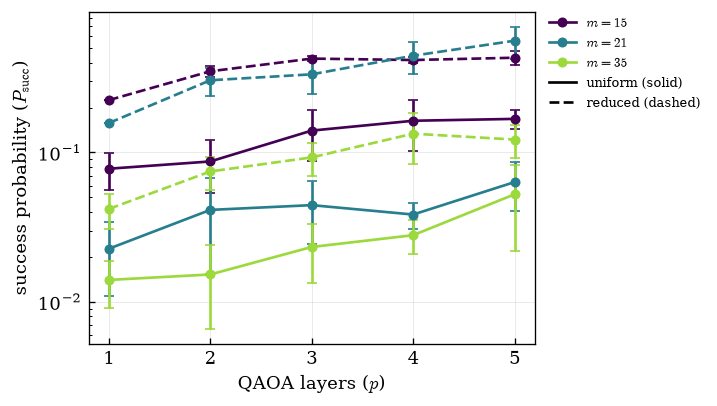

In [234]:
import numpy as np
from matplotlib.lines import Line2D

# success is multiplier-invariant; restrict to hrs so seed counts are not
# inflated by the (identical) rows of the other multipliers. All biprimes are
# overlaid on one plot: colour encodes m, line style encodes the variant
# (solid = uniform, dashed = reduced); mean +/- std over the optimizer seeds.
dfh = df[df['multiplier'] == 'hrs']
ms = sorted(dfh['m'].unique())
variant_style = {'uniform': '-', 'reduced': '--'}
colors = plt.cm.viridis(np.linspace(0, 0.85, len(ms)))
color_of = dict(zip(ms, colors))

fig, ax = plt.subplots(figsize=(4.8, 3.6))
for m in ms:
    sub_m = dfh[dfh['m'] == m]
    for variant, ls in variant_style.items():
        sv = sub_m[sub_m['variant'] == variant]
        if not len(sv):
            continue
        g = sv.groupby('reps')['success_prob'].agg(['mean', 'std']).reset_index()
        mean = g['mean'].to_numpy()
        std = g['std'].fillna(0.0).to_numpy()
        # clip the lower error so mean-std stays positive (required for log y)
        lower = np.minimum(std, mean * 0.999)
        ax.errorbar(g['reps'], mean, yerr=[lower, std], ls=ls, marker='o',
                    capsize=3, color=color_of[m])
ax.set_xlabel('QAOA layers ($p$)')
ax.set_ylabel('success probability ($P_{\\mathrm{succ}}$)')
ax.set_yscale('log')
integer_axis(ax, 'x', dfh['reps'].unique())
# legend outside the axes: colour key (one per m) + line-style key for variants
color_handles = [Line2D([], [], color=color_of[m], marker='o', ls='-',
                        label=f'$m={int(m)}$') for m in ms]
style_handles = [Line2D([], [], color='black', ls='-', label='uniform (solid)'),
                 Line2D([], [], color='black', ls='--', label='reduced (dashed)')]
ax.legend(handles=color_handles + style_handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
fig.savefig(os.path.join(run_dir, 'qaoa_success_vs_layers.pdf'),
            bbox_inches='tight')
plt.show()

## 2. Resource scaling vs. number of layers

Gate and depth counts vs. the layer count $p$ for the **hrs** multiplier
(Qiskit's `HRSCumulativeMultiplier`, the one used throughout this study). Both
variants are overlaid: colour encodes the biprime $m$, line style encodes the
variant (solid = uniform, dashed = reduced). Each layer adds another
MUL / $R_z$ / MUL$^\dagger$ bracket, so the counts grow linearly in $p$; the
log scale separates the biprimes. The CNOT count is the headline metric
(two-qubit gates dominate NISQ error). The qubit count is fixed per biprime and
is tabulated below the plots.

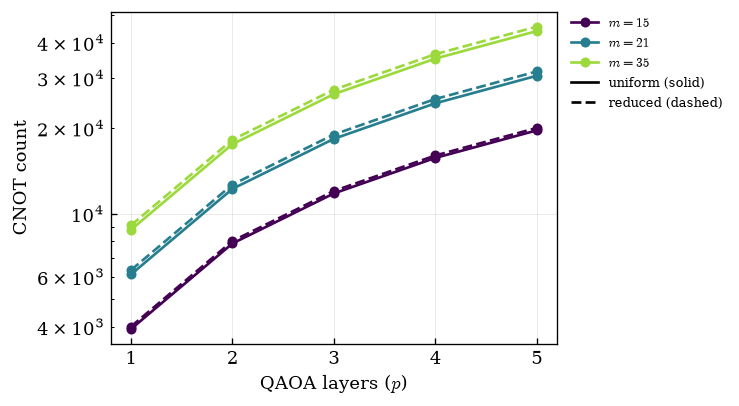

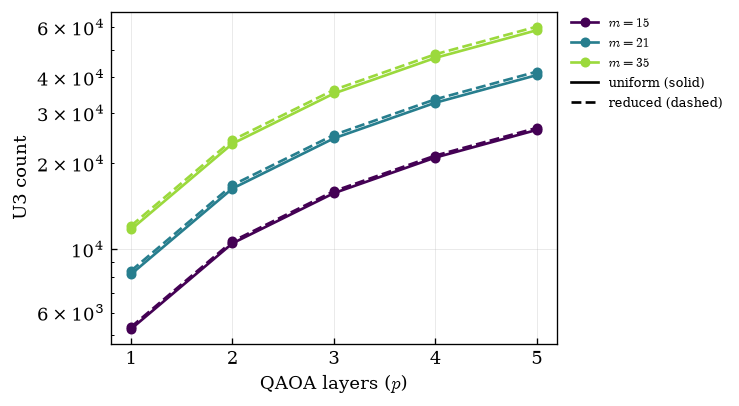

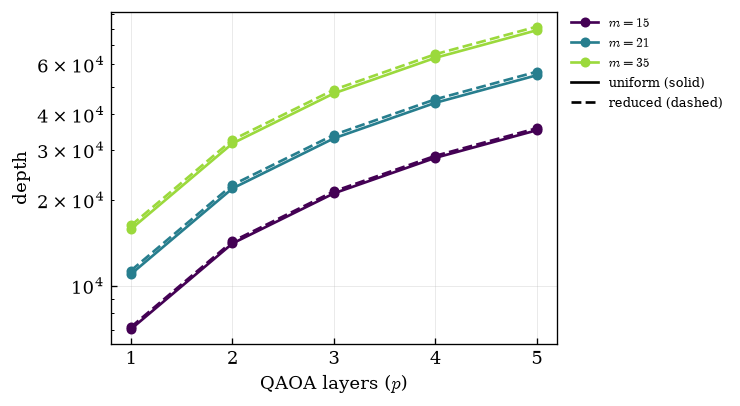

In [235]:
# (col, label, filename slug, y-scale)  -- qubit count is fixed, so it is
# tabulated below rather than plotted against p.
from matplotlib.lines import Line2D
metrics = [('cnot_count', 'CNOT count', 'cnot', 'log'),
           ('u3_count', 'U3 count', 'u3', 'log'),
           ('depth', 'depth', 'depth', 'log')]
# resources are seed-independent; report the hrs multiplier. Both variants are
# overlaid: colour encodes the biprime m, line style encodes the variant
# (solid = uniform, dashed = reduced), plotted against the layer count p.
base = (df[df['multiplier'] == 'hrs']
        .drop_duplicates(subset=['m', 'variant', 'reps'])
        .sort_values(['m', 'variant', 'reps']))
ms = sorted(base['m'].unique())
variant_style = {'uniform': '-', 'reduced': '--'}
colors = plt.cm.viridis(np.linspace(0, 0.85, len(ms)))
color_of = dict(zip(ms, colors))

for col, label, slug, yscale in metrics:
    if col not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(4.8, 3.6))
    for m in ms:
        for variant, ls in variant_style.items():
            s = base[(base['m'] == m) & (base['variant'] == variant)]
            if not len(s):
                continue
            ax.plot(s['reps'], s[col], ls=ls, marker='o', color=color_of[m])
    ax.set_xlabel('QAOA layers ($p$)')
    ax.set_ylabel(label)
    integer_axis(ax, 'x', base['reps'].unique())
    if yscale == 'log':
        ax.set_yscale('log')
    # legend outside the axes: colour key (one per m) + line-style key
    color_handles = [Line2D([], [], color=color_of[m], marker='o', ls='-',
                            label=f'$m={int(m)}$') for m in ms]
    style_handles = [Line2D([], [], color='black', ls='-', label='uniform (solid)'),
                     Line2D([], [], color='black', ls='--', label='reduced (dashed)')]
    ax.legend(handles=color_handles + style_handles, fontsize=8, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.savefig(os.path.join(run_dir, f'qaoa_{slug}_vs_p.pdf'),
                bbox_inches='tight')
    plt.show()

### Qubit count (fixed per biprime)

The number of qubits is set by the biprime $m$ and the multiplier (hrs), and is
independent of the layer count $p$ and the optimizer seed, so it is tabulated
rather than plotted. Written to `qubit_counts.csv` in the run folder.

In [236]:
# Qubit count is fixed per (m, variant) for the hrs multiplier.
qubits = (df[df['multiplier'] == 'hrs']
          .groupby(['m', 'variant'])['n_qubits'].first()
          .unstack('variant'))
# order columns uniform, reduced when present
qubits = qubits[[c for c in ['uniform', 'reduced'] if c in qubits.columns]]
# qubit counts are integers; nullable Int64 keeps them integer-typed even when
# a variant has not been run yet (missing shows as <NA>, not 25.0).
qubits = qubits.round().astype('Int64')
qubits.index.name = 'm'
qubits.to_csv(os.path.join(run_dir, 'qubit_counts.csv'))
qubits

variant,uniform,reduced
m,,
15,17,17
21,21,21
35,25,25


## 3. Simulation runtime

Wall-clock time of the full QAOA optimization for each config (all seed
restarts together) vs. the layer count $p$, one curve per biprime $m$, both
variants overlaid (solid = uniform, dashed = reduced). This is the time COBYLA
spends driving the circuit, dominated by the **statevector simulations** at each
objective evaluation rather than by the classical optimizer; it excludes the
one-time ansatz build and transpilation (decomposed once, before timing).
Runtime grows with $p$ (deeper circuits, more parameters) and with $m$ (larger
statevectors), and is the practical wall on how far the statevector sweep can
be pushed. Log $y$-axis. Saved as `qaoa_runtime_vs_p.pdf`.

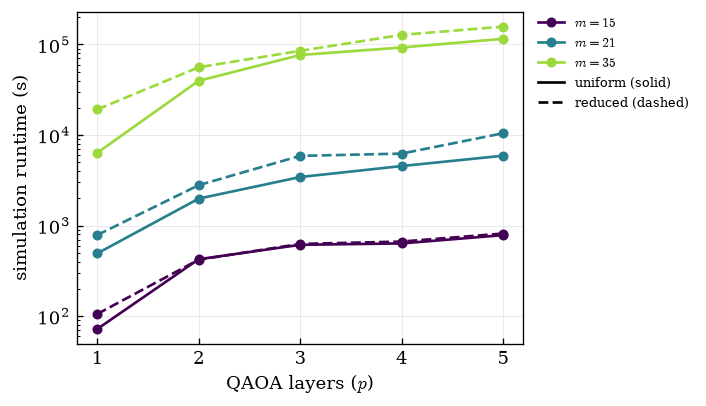

In [237]:
# Simulation runtime is recorded once per (m, variant, reps) config (total over
# the seed restarts, dominated by the statevector evaluations). Report the hrs
# multiplier; both variants overlaid, colour = biprime m, line style = variant
# (solid = uniform, dashed = reduced), plotted against the layer count p.
from matplotlib.lines import Line2D
rt = (df[df['multiplier'] == 'hrs']
      .drop_duplicates(subset=['m', 'variant', 'reps'])
      .sort_values(['m', 'variant', 'reps']))
ms = sorted(rt['m'].unique())
variant_style = {'uniform': '-', 'reduced': '--'}
colors = plt.cm.viridis(np.linspace(0, 0.85, len(ms)))
color_of = dict(zip(ms, colors))

fig, ax = plt.subplots(figsize=(4.8, 3.6))
for m in ms:
    for variant, ls in variant_style.items():
        s = rt[(rt['m'] == m) & (rt['variant'] == variant)]
        if not len(s):
            continue
        ax.plot(s['reps'], s['opt_seconds'], ls=ls, marker='o', color=color_of[m])
ax.set_xlabel('QAOA layers ($p$)')
ax.set_ylabel('simulation runtime (s)')
ax.set_yscale('log')
integer_axis(ax, 'x', rt['reps'].unique())
color_handles = [Line2D([], [], color=color_of[m], marker='o', ls='-',
                        label=f'$m={int(m)}$') for m in ms]
style_handles = [Line2D([], [], color='black', ls='-', label='uniform (solid)'),
                 Line2D([], [], color='black', ls='--', label='reduced (dashed)')]
ax.legend(handles=color_handles + style_handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
fig.savefig(os.path.join(run_dir, 'qaoa_runtime_vs_p.pdf'), bbox_inches='tight')
plt.show()

## 4. Search-space reduction

The **search-space size** is $\log_2$ of the number of basis states spanning the
initial state, and the **reduction ratio** is reduced size / uniform size (a
ratio below 1 means a genuine reduction). Left: reduction ratio per biprime
(bars below the dashed 1.0 line). Right: absolute uniform vs. reduced sizes.

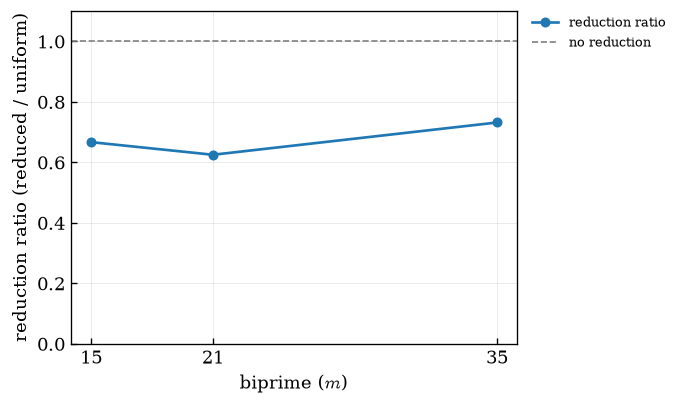

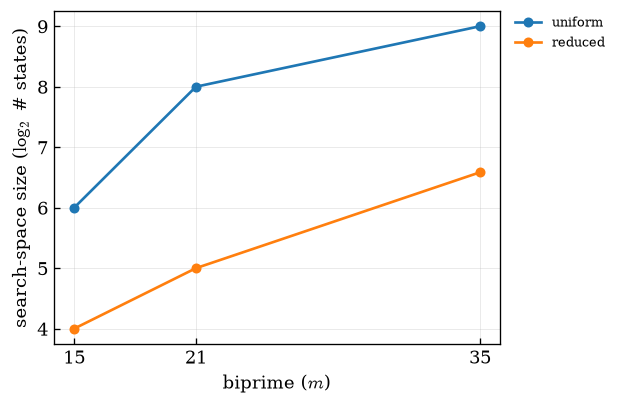

In [238]:
if 'reduction_ratio' not in df.columns:
    print('This run predates the search-space-size columns; skipping reduction plot.')
else:
    red = (df[df['variant'] == 'reduced']
           .groupby('m')[['search_space_size', 'reduction_ratio']].first().reset_index()
           .sort_values('m'))
    uni = (df[df['variant'] == 'uniform']
           .groupby('m')['search_space_size'].first())

    if len(red):
        # (a) reduction ratio vs m (curve)
        fig, ax = plt.subplots(figsize=(4.8, 3.6))
        ax.plot(red['m'], red['reduction_ratio'], marker='o', color='C0',
                label='reduction ratio')
        ax.axhline(1.0, color='gray', ls='--', lw=1, label='no reduction')
        ax.set_xlabel('biprime ($m$)')
        ax.set_ylabel('reduction ratio (reduced / uniform)')
        ax.set_ylim(0, 1.1)
        integer_axis(ax, 'x', red['m'].unique())
        ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0),
                  borderaxespad=0.0)
        fig.savefig(os.path.join(run_dir, 'qaoa_reduction_ratio.pdf'),
                    bbox_inches='tight')
        plt.show()

        # (b) absolute search-space sizes vs m
        fig, ax = plt.subplots(figsize=(4.8, 3.6))
        ax.plot(red['m'], [uni.get(m) for m in red['m']], marker='o', label='uniform')
        ax.plot(red['m'], red['search_space_size'], marker='o', label='reduced')
        ax.set_xlabel('biprime ($m$)')
        ax.set_ylabel('search-space size ($\\log_2$ # states)')
        integer_axis(ax, 'x', red['m'].unique())
        ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0),
                  borderaxespad=0.0)
        fig.savefig(os.path.join(run_dir, 'qaoa_search_space_size.pdf'),
                    bbox_inches='tight')
        plt.show()
    else:
        print('No reduced-variant rows in this run; skipping reduction plot.')

## Summary table

For each $(m, \text{variant})$ this reports the layer count $p$ with the
**highest mean success probability**, together with that configuration's seed
statistics (`success_mean`, `success_std`, `success_best`) and its
(seed-independent) resource costs. Written to `summary.csv` in the run folder.

In [239]:
# Restrict to hrs (the reported multiplier); success is multiplier-invariant.
dfh = df[df['multiplier'] == 'hrs']
# Aggregate success across seeds per (m, variant), reporting the best layer count.
agg = (dfh.groupby(['m', 'variant', 'reps'])['success_prob']
         .agg(success_mean='mean', success_std='std', success_best='max', n_seeds='count')
         .reset_index())
# pick, per (m, variant), the layer count with the highest mean success
best_idx = agg.groupby(['m', 'variant'])['success_mean'].idxmax()
summary = agg.loc[best_idx].reset_index(drop=True)

# attach the (seed-independent) resource columns
res_cols = [c for c in ['n_qubits', 'depth', 'cnot_count', 'u3_count',
                        'search_space_size', 'reduction_ratio'] if c in dfh.columns]
res = dfh.drop_duplicates(subset=['m', 'variant', 'reps'])[
    ['m', 'variant', 'reps'] + res_cols]
summary = summary.merge(res, on=['m', 'variant', 'reps'], how='left')
summary = summary.sort_values(['m', 'variant']).reset_index(drop=True)
summary.to_csv(os.path.join(run_dir, 'summary.csv'), index=False)
summary

,m,variant,reps,success_mean,success_std,success_best,n_seeds,n_qubits,depth,cnot_count,u3_count,search_space_size,reduction_ratio
0,15,reduced,5,0.430947,0.046978,0.488038,5,17,35774,20050,26610,4.000,0.6667
1,15,uniform,5,0.167817,0.023393,0.188860,5,17,35196,19660,26190,6.000,1.0000
2,21,reduced,5,0.560289,0.135575,0.717563,5,21,56524,31681,41905,5.000,0.6250
3,21,uniform,5,0.063339,0.022891,0.097152,5,21,54946,30600,40764,8.000,1.0000
4,35,reduced,4,0.133608,0.050253,0.223058,5,25,65136,36441,48219,6.585,0.7317
5,35,uniform,5,0.052458,0.030560,0.096058,5,25,79086,43950,58547,9.000,1.0000


## 5. Impact of noise ($m = 15$)

Loads the noisy-simulation sweep from `scripts/run_noisy_simulation.py` (the
latest run folder with a `qaoa_noisy.csv`). Each **seed** is an independent
optimizer restart: it optimizes its own QAOA angles, then those angles are
evaluated noise-free (exact) and under a depolarizing $+$ readout noise model at
each two-qubit **error rate** $\epsilon$ (shot-based sampling).

The plot shows $P_{\mathrm{succ}}$ vs. layers $p$: the black square curve is the
noise-free reference, the coloured curves are the noisy successes (one per
$\epsilon$), line style encodes the variant (solid $=$ uniform, dashed $=$
reduced). Error bars are the mean $\pm$ std across the optimizer seeds on every
curve, so the noise-free baseline carries the same spread as the success-vs-layers
plot above. Saved as `qaoa_noise_sweep.pdf`.

Loaded 200 rows from ../results\noisy_m15/qaoa_noisy.csv  (m=15, 256 shots)


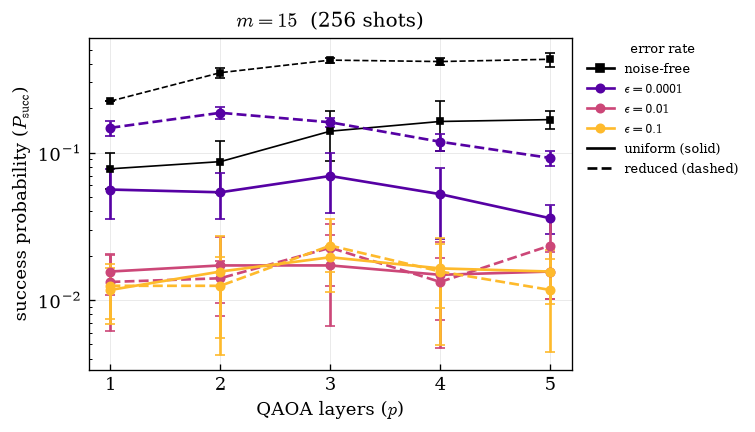

Loaded 126 rows from ../results\noisy_m15_2048/qaoa_noisy.csv  (m=15, 2048 shots)


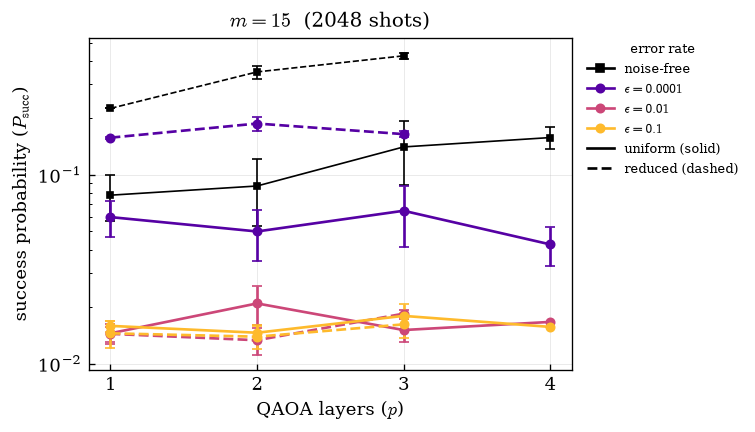

Loaded 73 rows from ../results\noisy_m21/qaoa_noisy.csv  (m=21, 256 shots)


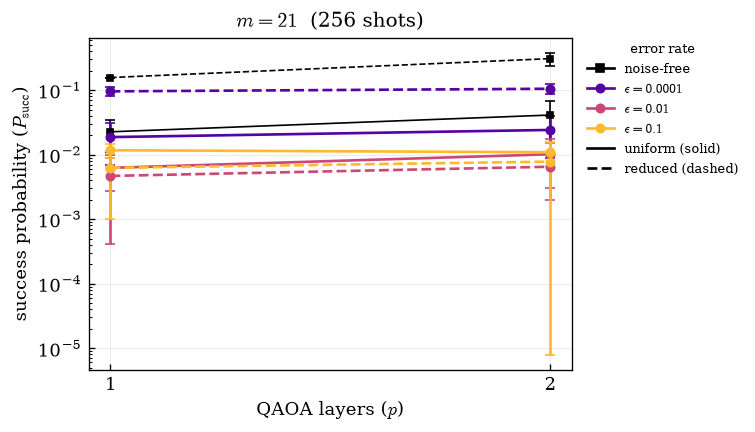

In [240]:
# Noise sweep: success vs layers (p), one figure PER run folder (e.g. m=15, m=21).
# Each row is one optimizer seed; error_rate = -1 rows are the noise-free
# baseline. Error bars are the mean +/- std across optimizer seeds, on every
# curve including the baseline.
from matplotlib.lines import Line2D

def noisy_dirs(base='../results'):
    out = []
    for csv in sorted(glob.glob(os.path.join(base, '*', 'qaoa_noisy.csv'))):
        if os.path.getsize(csv) > 0 and len(pd.read_csv(csv)) > 0:
            out.append(os.path.dirname(csv))
    return out

def plot_noise_sweep(noisy_dir):
    ndf = pd.read_csv(os.path.join(noisy_dir, 'qaoa_noisy.csv'))
    m = int(ndf['m'].iloc[0])
    shots = int(ndf['shots'].iloc[0])
    print(f'Loaded {len(ndf)} rows from {noisy_dir}/qaoa_noisy.csv  (m={m}, {shots} shots)')

    variant_style = {'uniform': '-', 'reduced': '--'}
    base = ndf[ndf['error_rate'] < 0]
    noisy = ndf[ndf['error_rate'] > 0]
    rates = sorted(noisy['error_rate'].unique())
    # start the colourmap away from the dark end so no error-rate colour
    # clashes with the black noise-free baseline
    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(rates)))
    color_of = dict(zip(rates, colors))

    fig, ax = plt.subplots(figsize=(5.2, 3.6))
    for variant, ls in variant_style.items():
        s = base[base['variant'] == variant]
        if not len(s):
            continue
        g = s.groupby('reps')['success_ideal'].agg(['mean', 'std']).reset_index().sort_values('reps')
        lower = np.minimum(g['std'].fillna(0.0), g['mean'] * 0.999)
        ax.errorbar(g['reps'], g['mean'], yerr=[lower, g['std'].fillna(0.0)],
                    ls=ls, marker='s', ms=4, color='black', lw=1.0, capsize=3)
    for er in rates:
        for variant, ls in variant_style.items():
            s = noisy[(noisy['error_rate'] == er) & (noisy['variant'] == variant)]
            if not len(s):
                continue
            g = s.groupby('reps')['success_noisy'].agg(['mean', 'std']).reset_index().sort_values('reps')
            lower = np.minimum(g['std'].fillna(0.0), g['mean'] * 0.999)
            ax.errorbar(g['reps'], g['mean'], yerr=[lower, g['std'].fillna(0.0)],
                        ls=ls, marker='o', capsize=3, color=color_of[er])
    ax.set_title(f'$m = {m}$  ({shots} shots)')
    ax.set_xlabel('QAOA layers ($p$)')
    ax.set_ylabel(r'success probability ($P_{\mathrm{succ}}$)')
    ax.set_yscale('log')
    integer_axis(ax, 'x', ndf['reps'].unique())

    color_handles = ([Line2D([], [], color='black', marker='s', ls='-', label='noise-free')]
                     + [Line2D([], [], color=color_of[er], marker='o', ls='-',
                               label=fr'$\epsilon={er:g}$') for er in rates])
    style_handles = [Line2D([], [], color='black', ls='-', label='uniform (solid)'),
                     Line2D([], [], color='black', ls='--', label='reduced (dashed)')]
    ax.legend(handles=color_handles + style_handles, fontsize=8, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              title='error rate', title_fontsize=8)
    fig.savefig(os.path.join(noisy_dir, f'qaoa_noise_sweep_m{m}_{shots}shots.pdf'), bbox_inches='tight')
    plt.show()

dirs = noisy_dirs()
if not dirs:
    print('No */qaoa_noisy.csv found; run scripts/run_noisy_simulation.py first.')
else:
    for d in dirs:
        plot_noise_sweep(d)